# model_training and evaluation

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Naive Bayes Accuracy: 0.9729206963249516
Logistic Regression Accuracy: 0.9584139264990329
SVM Accuracy: 0.9825918762088974
Random Forest Accuracy: 0.971953578336557
----- Naive Bayes -----
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034

----- Logistic Regression -----
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       889
           1       0.95      0.74      0.83       145

    accuracy                           0.96      1034
   macro avg       0.95      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034

----- SVM -----
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889


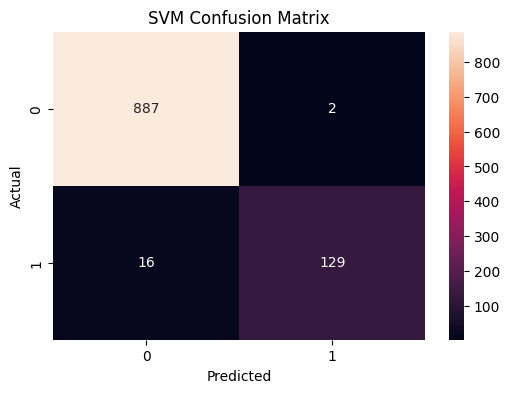

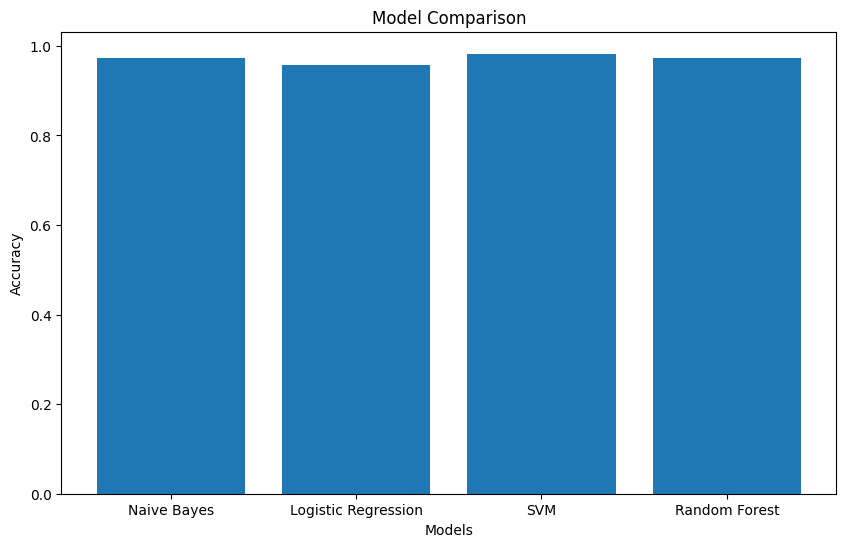

In [4]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df = df.drop_duplicates(keep='first')

df['label'] = df['label'].map({'ham':0, 'spam':1})

# Downloads
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Stemmer
ps = PorterStemmer()

# Transform Function
def transform_text(text):

    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]

    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]

    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

# Apply Transformation
df['transformed_message'] = df['message'].apply(transform_text)

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_message']).toarray()

y = df['label'].values

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Initialize Models
nb_model = MultinomialNB()

lr_model = LogisticRegression(max_iter=1000)

svm_model = SVC(kernel='linear')

rf_model = RandomForestClassifier(n_estimators=100)

# Train Models
nb_model.fit(X_train, y_train)

lr_model.fit(X_train, y_train)

svm_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)

lr_pred = lr_model.predict(X_test)

svm_pred = svm_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

# Accuracy Scores
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Classification Reports

print("----- Naive Bayes -----")
print(classification_report(y_test, nb_pred))

print("----- Logistic Regression -----")
print(classification_report(y_test, lr_pred))

print("----- SVM -----")
print(classification_report(y_test, svm_pred))

print("----- Random Forest -----")
print(classification_report(y_test, rf_pred))

# Confusion Matrix for SVM

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title('SVM Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Model Comparison Graph

models = [
    'Naive Bayes',
    'Logistic Regression',
    'SVM',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(10,6))

plt.bar(models, accuracies)

plt.title('Model Comparison')

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.show()